<a target="_blank" href="https://colab.research.google.com/github/taobrienlbl/advanced_earth_science_data_analysis/blob/fall_2025_iub/content/lessons/09_machine_learning_intro/09_workalong_machine_learning_basics.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Work-along: Machine Learning Basics

This workalong walks through some of the basic elements of modern machine learning, including *rectified linear units (reLU)*, *loss functions*, *backpropagation*, and the use of `pytorch`.

```{note}
Download this notebook and place it in your lesson 09 folder.
```

<div style="max-width:720px"><div style="position:relative;padding-bottom:56.25%"><iframe id="kaltura_player" src='https://cdnapisec.kaltura.com/p/1751071/embedPlaykitJs/uiconf_id/55382703?iframeembed=true&amp;entry_id=1_mq40leww&amp;config%5Bprovider%5D=%7B%22widgetId%22%3A%221_2cr2ouqb%22%7D&amp;config%5Bplayback%5D=%7B%22startTime%22%3A0%7D'  allowfullscreen webkitallowfullscreen mozAllowFullScreen allow="autoplay *; fullscreen *; encrypted-media *" sandbox="allow-downloads allow-forms allow-same-origin allow-scripts allow-top-navigation allow-pointer-lock allow-popups allow-modals allow-orientation-lock allow-popups-to-escape-sandbox allow-presentation allow-top-navigation-by-user-activation" title="EAS-G 690 Lesson 09 - reLUs and manual optimization" style="position:absolute;top:0;left:0;width:100%;height:100%;border:0"></iframe></div></div>

*Use [this link](https://iu.mediaspace.kaltura.com/media/t/1_mq40leww) if you encounter issues with playing the embedded video above.*

## Rectified linear units (reLU)

In the cell below, implement two functions:
 1. `linear(x,w,b)`
 2. `relu(x)` 

as indicated in the functions' docstrings.  (Note, remove the lines with `pass` - this is just a line of code that says to Python "do nothing"...it's necessary because functions can't be empty in Python.)

Test that it works as expected, and keep your tests in the notebook.

In [86]:
""" Define a linear and relu function. """
import numpy as np
import matplotlib.pyplot as plt

def linear(x : np.ndarray, w : float = 1, b : float = 0) -> np.ndarray:
    """ returns w*x + b """
    return w*x + b

def relu(x : np.ndarray) -> np.ndarray:
    """ returns x if x is positive, 0 otherwise"""
    result = np.where(x > 0, x, x*0)
    return result


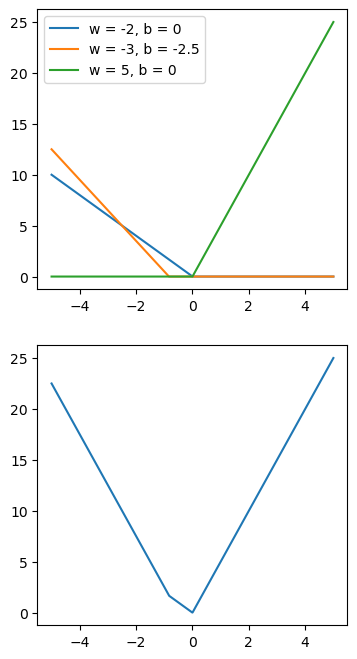

In [87]:
""" Test the relu function. """

w = [-2,-3,5]
b = [0,-2.5,0]

x = np.linspace(-5,5,1000)

fig, axs = plt.subplots(2,1,figsize = (4,8))

ax = axs[0]
for w_i, b_i in zip(w,b):
    ax.plot(x, relu(linear(x,w_i,b_i)), label = f"w = {w_i}, b = {b_i}")
ax.legend()

ax = axs[1]
y = np.zeros_like(x)
for w_i, b_i in zip(w,b):
    y = y + relu(linear(x,w_i,b_i))
ax.plot(x,y)

plt.show()

## Fitting a function with reLUs

1. Run the cell below to create a graph of fake, noisy data (variable `noisy_data`).
1. In the cell below that, create a function `relu_sum` that is the sum of two reLUs with a bias (a scalar) added at the end
1. Create a new plot that includes the function output and the noisy data
1. Adjust the `w` and `b` parameters until the function approximates the fake data.
1. Comment in a markdown cell on your observations, what you learned, etc.



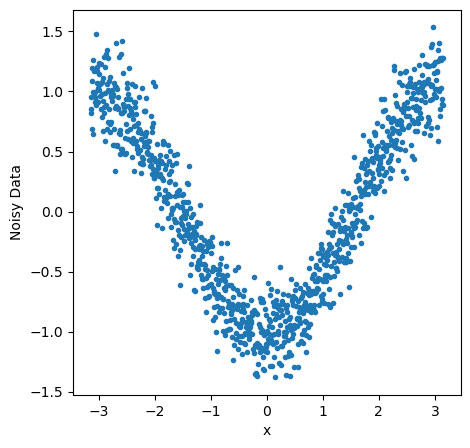

In [88]:
""" Create a fake, noisy dataset. """
import matplotlib.pyplot as plt

# define the x values
x = np.linspace(-np.pi, np.pi, 1000)

# define the y values of the true function
y_true = -np.cos(x)

# add some noise to the true function
np.random.seed(5984)
noisy_data = y_true + np.random.normal(0, 0.2, len(x))

# plot the noisy data
fig, ax = plt.subplots(figsize = (5,5))
ax.plot(x, noisy_data, '.', label="data")
ax.set_xlabel("x")
ax.set_ylabel("Noisy Data")
plt.show()

In [89]:
""" Define a function that is the sum of two relus. """

def relu_sum(x : np.ndarray, w : np.ndarray, b : np.ndarray, bias : float = 0) -> np.ndarray:
    """ returns relu(w[0]*x + b[0]) + relu(w[1]*x + b[1]) + bias """
    # check that w and b are the same length
    assert len(w) == len(b), "w and b must be the same length"
    
    y = np.zeros_like(x) + bias
    
    for w_i, b_i in zip(w,b):
        y += relu(linear(x, w_i, b_i))
    return y

In [90]:
relu_sum(np.array([2,3,-5,6]),np.array([3,4,5,-2]),np.array([-2,3,-2,6]),8)

array([33, 43, 24, 79])

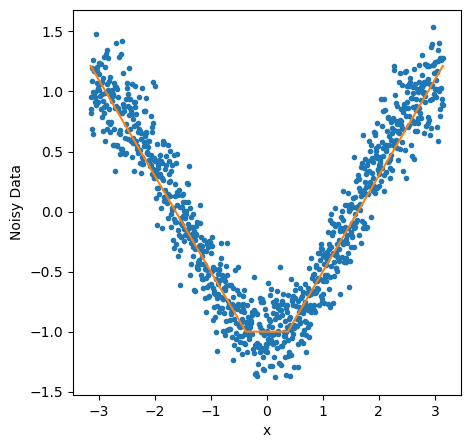

In [91]:
""" Plot the sum of two relus, with w, b such that the function fits the data. """

# set the weights, the offsets, and the bias
w = [-0.8,  0.8]
b = [-0.3, -0.3]
bias = -1

# plot the noisy data and fit
fig, ax = plt.subplots(figsize = (5,5))
ax.plot(x, noisy_data, '.', label="data")
ax.plot(x, relu_sum(x, w, b, bias = bias), label="fit")
ax.set_xlabel("x")
ax.set_ylabel("Noisy Data")
plt.show()

## Loss function

Now define a *loss* function $\mathcal{L}$: in this case *mean-squared error (MSE)* for the fit $\hat{\mathbf{z}}$ relative to the data $\mathbf{z}$

$$ \mathcal{L} = \frac{1}{N} \sum\limits_{i=0}^{N-1} (z_i - \hat{z}_i)^2$$

Calculate the loss for your fit to the data above: we'll compare in class.

In [92]:
""" Define a loss function. """

def loss(y_true : np.ndarray, y_pred : np.ndarray) -> float:
    """ returns the mean squared error between y_true and y_pred """
    return np.mean((y_true - y_pred)**2)
    pass

# calculate the loss for the fit
z_fit = relu_sum(x, w, b, bias = bias)

print(f"The loss for the fit is {loss(noisy_data, z_fit):.3f}")

The loss for the fit is 0.047


Add the loss to the title of the plot, and vary the parameters further to see if you can minimize the loss.

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2468067/1323350581.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("$\mathcal{L}$ = " +  f"{mse:.3f}")


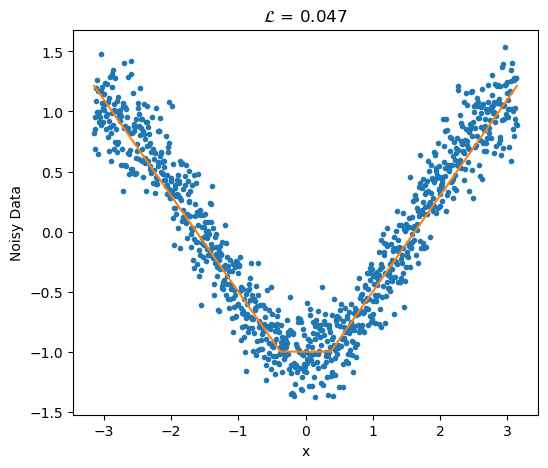

In [93]:
""" Vary parameters, minimizing the loss (include loss in title). """

# set the weights, the offsets, and the bias
w = [-0.8,  0.8]
b = [-0.3, -0.3]
bias = -1

# calculate the loss for the fit
z_fit = relu_sum(x, w, b, bias = bias)

# calculate the loss
mse = loss(noisy_data, z_fit)

# plot the noisy data and fit
fig, ax = plt.subplots(figsize = (6,5))
ax.plot(x, noisy_data, '.', label="data")
ax.plot(x, relu_sum(x, w, b, bias = bias), label="fit")
ax.set_xlabel("x")
ax.set_ylabel("Noisy Data")
ax.set_title("$\mathcal{L}$ = " +  f"{mse:.3f}")
plt.show()


## ReLUs in `pytorch`

```{note}
This section does not yet have a video recording.
```

Now we'll take advantage of `pytorch` for automating the process of fitting a NN model.

In [94]:
""" Define a neural network with a single hidden layer. """
# import pytorch
import torch
import torch.nn as nn
# set the random seed for reproducibility
torch.manual_seed(5984)

class MyNet(nn.Module):
    def __init__(self, n_relus : int = 2):
        # initialize the parent class
        super().__init__()

        # note the use of 1 in the following: this is the dimensionality of the input (1D)
        # the extra linear layer serves to sum the relu terms and add a bias
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(1, n_relus),
            nn.ReLU(),
            nn.Linear(n_relus, 1)
        )

    def forward(self, x):
        """ Define the forward pass; how the network should act like a function"""
        out = self.linear_relu_stack(x)
        return out


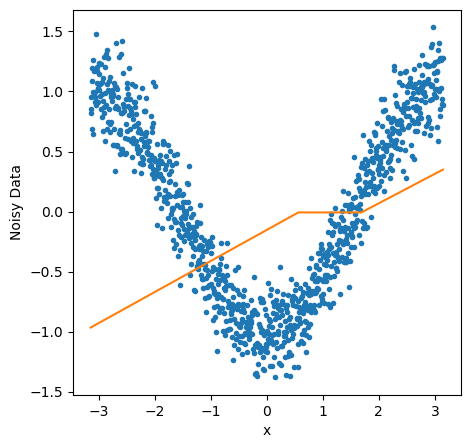

In [95]:
# convert x and y to pytorch tensors
#unsqueeze - converts x from 1D to 2D
# to - converts x from typ double (64 bit) to float (32 bit)

xt = torch.from_numpy(x).unsqueeze(1).to(torch.float32) #THIS IS VERY IMPORTANT
yt = torch.from_numpy(noisy_data).unsqueeze(1).to(torch.float32) #THIS IS VERY IMPORTANT

model_2 = MyNet(n_relus=2)

pred = model_2(xt)

#plot the noisy data
fig, ax = plt.subplots(figsize = (5,5))
ax.plot(x, noisy_data, '.', label="data")
ax.plot(x, pred.detach().numpy(),label='fit')
ax.set_xlabel("x")
ax.set_ylabel("Noisy Data")
plt.show()

In [96]:
""" Show the initial model prediction/fit (it's bad)"""


" Show the initial model prediction/fit (it's bad)"

### Training the model - the simple, but not-so-great way

We'll use a simple for loop to train the model on all the data.  This is bad because we don't split the dataset into train, test, and validation sets; this can make our efforts prone to overfitting.

But for simplicity, we'll forge forward with this (inadvisable) approach.

In [97]:

""" Train the model the bad way. """

# set hyperparameters
learning_rate = 0.01
training_steps = 1000

# define the model (and set the random number generator seed for reproducibility)
torch.manual_seed(5895)
model_2 = MyNet(n_relus = 2)

# define the loss function
loss_fn = nn.MSELoss()

# define the optimizer
optim = torch.optim.Adam(model_2.parameters(), lr = learning_rate)

for n in range(training_steps):
    # calculate the prediction
    pred = model_2(xt)   
    
    # calculate the loss ()
    loss = loss_fn(pred, yt)
    
    # zero the gradients
    optim.zero_grad()
    
    # calculate the gradients of the paramet with respect to the loss
    loss.backward()
    
    # update the parameters
    optim.step()
    
    # print the loss every 100 steps
    if n % 100 == 0:
        print(f"Step {n}: {loss.item():.3f}")



Step 0: 1.642
Step 100: 0.444
Step 200: 0.383
Step 300: 0.284
Step 400: 0.140
Step 500: 0.073
Step 600: 0.054
Step 700: 0.049
Step 800: 0.047
Step 900: 0.047


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2468067/2881149780.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("$\mathcal{L}$ = " + f"{loss.item():.3f}")


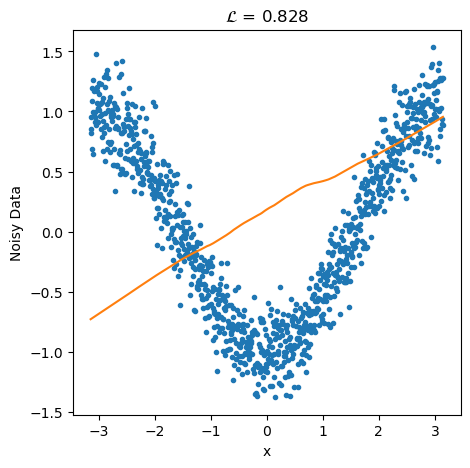

In [98]:
model_2 = MyNet(n_relus=200)

pred = model_2(xt)

# calculate the loss
loss = loss_fn(pred, yt)

# plot the noisy data
fig, ax = plt.subplots(figsize = (5,5))
ax.plot(x, noisy_data, '.', label="data")
ax.plot(x, pred.detach().numpy(),label='fit')
ax.set_xlabel("x")
ax.set_ylabel("Noisy Data")
ax.set_title("$\mathcal{L}$ = " + f"{loss.item():.3f}")
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2468067/1008361766.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("$\mathcal{L}$ = " +  f"{loss.item():.3f}")


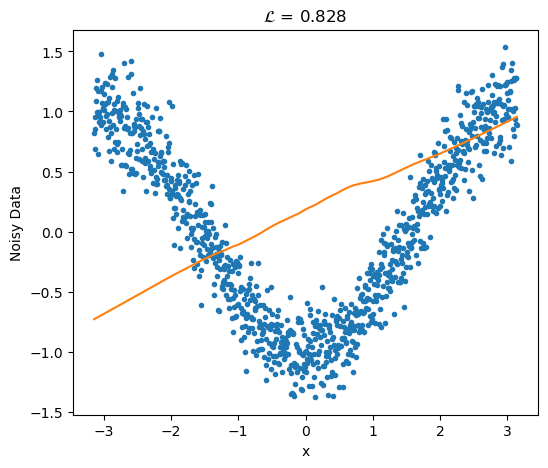

In [99]:
""" Plot the trained model. """
# calcuate the prediction
pred = model_2(xt)

# calculate the loss
loss = loss_fn(pred, yt)

# plot the noisy data and fit
fig, ax = plt.subplots(figsize = (6,5))
ax.plot(x, noisy_data, '.', label="data")
ax.plot(x, pred.detach().numpy(), label="fit")
ax.set_xlabel("x")
ax.set_ylabel("Noisy Data")
ax.set_title("$\mathcal{L}$ = " +  f"{loss.item():.3f}")
plt.show()

### Training the model - the better, but more complicated way

We'll follow standard practice here to split the data into test, train and validation sets.  We'll also use pytorch's data loader to do training in batches, and we'll put our training loop into a function.  This will allow us to train in *epochs* (passes through the entire dataset).

In [100]:
""" Train the model the better, but more complicated way. """

# set hyperparameters
learning_rate = 0.01
training_steps = 1000
training_fraction = 0.7
test_fraction = 0.2
valid_fraction = 1 - (training_fraction -test_fraction)
batch_size = 100
num_epochs = 100
assert valid_fraction > 0, "Choose different values for test_fraction and training_fraction; valid_fraction is"

# define the model (and set the random number generator seed for reproducibility)
torch.manual_seed(5895)
model_2 = MyNet(n_relus = 10000)

# define the loss function
loss_fn = nn.MSELoss()

# define the optimizer
optim = torch.optim.Adam(model_2.parameters(), lr = learning_rate)

#***********************************************
# define the test, training, and validation sets
#***********************************************
# create random indicies
i_random = np.random.choice(len(x), len(x), replace = False)
train_ind_max = int(len(x)*training_fraction)
train_inds = i_random[0:train_ind_max]
# define indices for testing data
test_ind_max = train_ind_max + int(len(x)*test_fraction)
test_inds = i_random[train_ind_max:test_ind_max]
# for validation data
valid_inds = i_random[test_ind_max:]
print(f"training: {len(train_inds)}, test: {len(test_inds)}, valid: {len(valid_inds)}")

# define data loaders for the test, training, and validation datasets
from torch.utils.data import TensorDataset, DataLoader
#define a training loop
train_ds = TensorDataset(xt[train_inds], yt[train_inds])
test_ds = TensorDataset(xt[test_inds], yt[test_inds])
valid_ds = TensorDataset(xt[valid_inds], yt[valid_inds])
#
train_dl = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
test_dl = DataLoader(test_ds, batch_size = batch_size, shuffle = True)
valid_dl = DataLoader(valid_ds, batch_size = batch_size, shuffle = True)
#define a testing loop



training: 700, test: 200, valid: 100


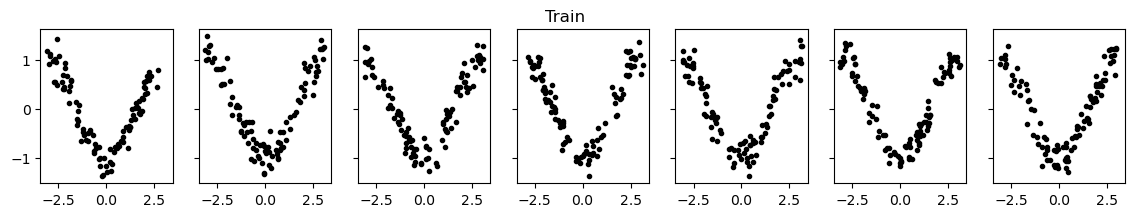

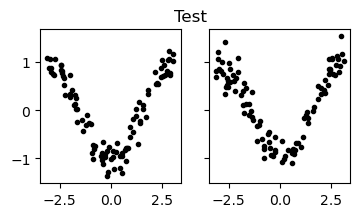

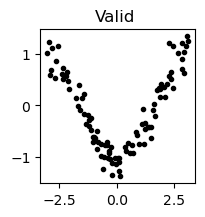

832.8988261904035
267.1659698656627
142.1668485232762
69.39277451378959
34.78517082759312
15.960959706987653
7.525349651064191
3.9318523577281406
1.9521402418613434
1.0819278519068445


np.float64(1.4877214431762695)

In [101]:
#data_loader = train_dl

def visualize_dataloader(data_loader, title = None):
    N = len(data_loader)

    # creat a 1xN figure
    fig, axs = plt.subplots(1,N,sharex=True, sharey=True, figsize=(2*N,2))

    #loop over batches and plot
    for batch, (xx,yy) in enumerate(data_loader):
        #set the plot axis
        try: 
            ax = axs[batch]
        except TypeError:
            ax = axs
        ax.plot(xx,yy,"k.")
    
    #add the title
    fig.suptitle(title)
    plt.show()

visualize_dataloader(train_dl, "Train")
visualize_dataloader(test_dl, "Test")
visualize_dataloader(valid_dl, "Valid")

# define the model (and set the random number generator seed for reproducibility)
torch.manual_seed(5895)
model_2 = MyNet(n_relus = 10000)

# define the loss function
loss_fn = nn.MSELoss()

# define the optimizer
optim = torch.optim.Adam(model_2.parameters(), lr = learning_rate)

def train_loop(data_loader, model, loss_fn, optim):
    
    model.train()
    
    # initialize the loss list
    batch_loss = []
    
    for batch, (xx,yy) in enumerate(data_loader):
    
        #Changes:
        # *xt -> xx
        # *yt -> yy
        # *model_2 -> model
    
        pred = model(xx)
        
        # calculate the loss ()
        loss = loss_fn(pred, yy)
        
        # zero the gradients
        optim.zero_grad()
        
        # calculate the gradients of the paramet with respect to the loss
        loss.backward()
        
        # update the parameters
        optim.step()
        
        batch_loss.append(loss.item())
        
    return np.mean(batch_loss)

for i in range(10):
    print(train_loop(train_dl, model_2, loss_fn, optim))

def test_loop(data_loader, model, loss_fn):
    # put the model in evaluation mode
    model.eval()
    
    batch_loss = []
    
    # loop over batches
    with torch.no_grad():
        #loop over bathes
        for batch, (xx,yy) in enumerate(data_loader):

        #run the model 
            pred = model(xx)
            #calculate the loss
            loss = loss_fn(pred, yy)
            
            #store the loss
            batch_loss.append(loss.item())
    
    #return average loss
    return np.mean(batch_loss)

test_loop(test_dl, model_2, loss_fn)



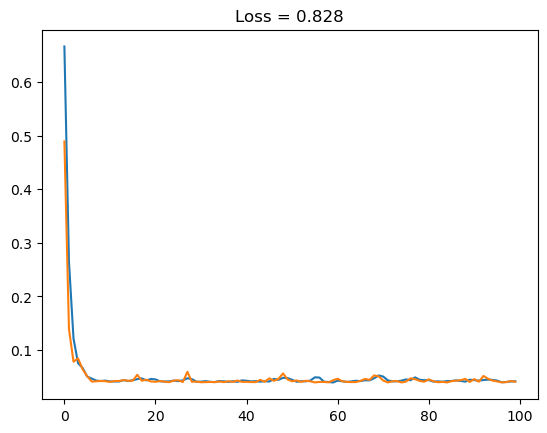

In [102]:
""" THomas the Tank Engine the Model """

# initialize lists to store the losses
train_loss = []
test_loss = []

# loop oer epochs
for epoch in range(num_epochs):

    # run a training loop
    train_loss_tmp = train_loop(train_dl, model_2, loss_fn, optim)
    
    # run a testing loop
    test_loss_tmp = test_loop(train_dl, model_2, loss_fn)
    
    #store the loss
    train_loss.append(train_loss_tmp)
    test_loss.append(test_loss_tmp)
    
# plot the losses as a function of epoch
fig, ax = plt.subplots()
ax.plot(train_loss, label = "Train")
ax.plot(test_loss, label = "test")

ax.set_title(f"Loss = {loss.item():.3f}")
plt.show()

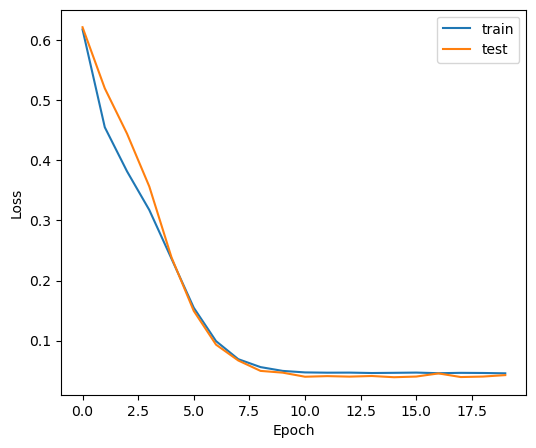

In [103]:
# set hyperparameters
learning_rate = 0.01
num_epochs = 20
batch_size = 32
training_fraction = 0.8
test_fraction = 0.1
n_relus = 2

# define the model
# set torch's random seed for reproducibility
torch.manual_seed(5984)
model_2 = Net(n_relus = n_relus)

# set the optimizer
optim = torch.optim.AdamW(model_2.parameters(), lr = learning_rate)

# set the loss function
loss_fn = nn.MSELoss()

# set the sizes of the training, test, and validation sets
n_train = int(training_fraction*len(x))
n_test = int(test_fraction*len(x))
n_val = len(x) - n_train - n_test

# create a random set of indices
np.random.seed(5984)
i_random = np.random.choice(len(x), len(x), replace = False)

# use the random indices to choose indices for the training, test, and validation sets
i_train = i_random[:n_train]
i_test = i_random[n_train:n_train+n_test]
i_val = i_random[n_train+n_test:]

# use the random indices to randomly split the data
x_train = xt[i_train]
x_test = xt[i_test]
x_val = xt[i_val]

# define data loaders for the training, test, and validation sets
from torch.utils.data import TensorDataset, DataLoader
train_ds = TensorDataset(x_train, yt[i_train])
test_ds = TensorDataset(x_test, yt[i_test])
val_ds = TensorDataset(x_val, yt[i_val])
train_dl = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
test_dl = DataLoader(test_ds, batch_size = batch_size, shuffle = False)
val_dl = DataLoader(val_ds, batch_size = batch_size, shuffle = False)

# define the training loop function
def train_loop(dataloader, model, loss_fn, optim):

    # set the model to training mode
    model.train()

    batch_loss = []

    # loop over the batches
    for batch, (xx, yy) in enumerate(dataloader):
        # zero the gradients
        optim.zero_grad()

        # run the model
        pred = model(xx)
        # calculate the loss
        loss = loss_fn(pred, yy)
        # calculate the gradient of the loss wrt the NN parameters
        loss.backward()

        # update the parameters
        optim.step()

        # save the loss
        batch_loss.append(loss.item())
    
    # return the average loss across batches
    return np.mean(batch_loss)
    

# define a test loop function
def test_loop(dataloader, model, loss_fn):
    
    # set the model to evaluation mode
    model.eval()

    # initialize the loss
    loss = 0

    # no need to calculate gradients when testing
    with torch.no_grad():
        # loop over the batches
        for xx, yy in dataloader:

            # calculate the prediction
            pred = model(xx)

            # calculate the loss
            loss += loss_fn(pred, yy).item()

    # return the average loss across batches
    return loss/len(dataloader)


# train the model
train_loss = []
test_loss = []
for epoch in range(num_epochs):
    # calculate the training loss
    train_loss_tmp = train_loop(train_dl, model_2, loss_fn, optim)
    train_loss.append(train_loss_tmp)
    # calculate the test loss
    test_loss_tmp = test_loop(test_dl, model_2, loss_fn)
    test_loss.append(test_loss_tmp)

# plot the training and test loss
fig, ax = plt.subplots(figsize = (6,5))
ax.plot(train_loss, label="train")
ax.plot(test_loss, label="test")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

In [104]:
#There is a csv file named 'WEATHER_-_2414781_Sep_15_2023_2_56_14_PM.csv' in the current directory. 
#From this file, extract the numbers from the columns named 'Barometric Pressure' and 'Altitude'.
#The Barometric Pressure numbers span column E, rows 6-41. Altitude is column F, rows 6-41.

import pandas as pd

csv_path = 'WEATHER_-_2414781_Sep_15_2023_2_56_14_PM.csv'

# Many exported CSVs contain metadata rows before the actual header.
# Try to read the file robustly: first attempt to treat row 5 (index 4) as header.
# If that fails, read without a header and pick columns E (index 4) and F (index 5) from rows 6-41.
try:
	df_values = pd.read_csv(csv_path, engine='python', header=4, usecols=['Barometric Pressure', 'Altitude'])
except Exception:
	# fallback: no reliable header, read rows 6-41 (skip first 5 rows), take columns 4 and 5 (E,F)
	df_values = pd.read_csv(
		csv_path,
		engine='python',
		header=None,
		skiprows=5,        # skip first 5 rows so row 6 becomes first row read
		usecols=[4, 5],    # columns E (index 4) and F (index 5)
		nrows=36           # rows 6-41 inclusive => 36 rows
	)
	df_values.columns = ['Barometric Pressure', 'Altitude']

# Convert values to numeric, stripping any non-numeric characters (units, commas, etc.)
df_values['Barometric Pressure'] = pd.to_numeric(
	df_values['Barometric Pressure'].astype(str).str.replace(r'[^0-9\.\+\-eE]', '', regex=True),
	errors='coerce'
)
df_values['Altitude'] = pd.to_numeric(
	df_values['Altitude'].astype(str).str.replace(r'[^0-9\.\+\-eE]', '', regex=True),
	errors='coerce'
)

# Drop missing rows and reset index
df_values = df_values.dropna().reset_index(drop=True)

# final series
barometric_pressure = df_values['Barometric Pressure']
altitude = df_values['Altitude']

# Assign to Barometric Pressure and Altitude values to lists
barometric_pressure_list = barometric_pressure.tolist()
altitude_list = altitude.tolist()

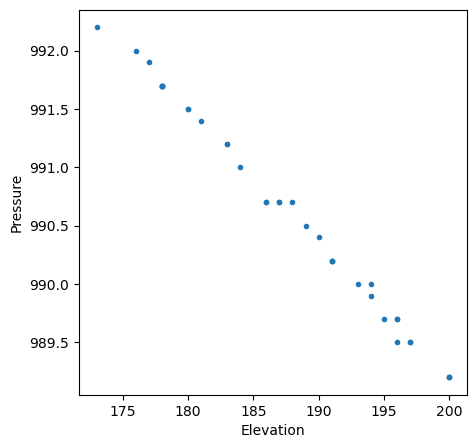

training: 25, test: 7, valid: 4


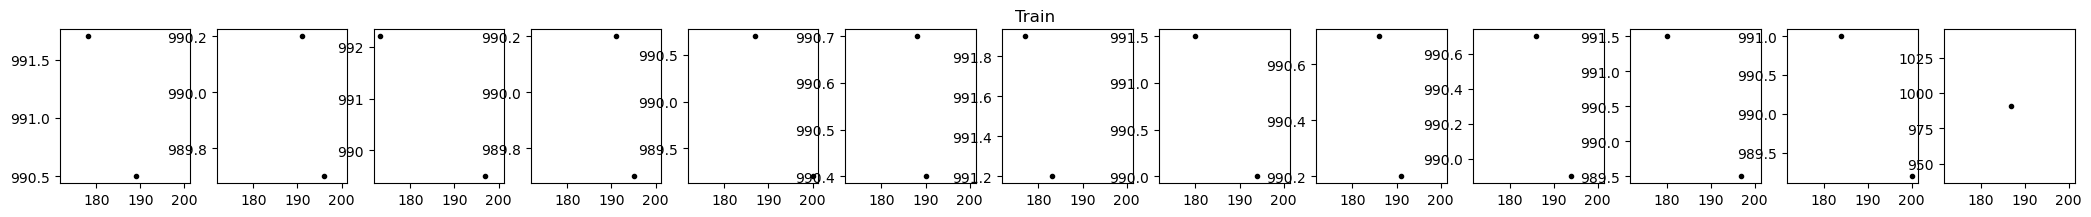

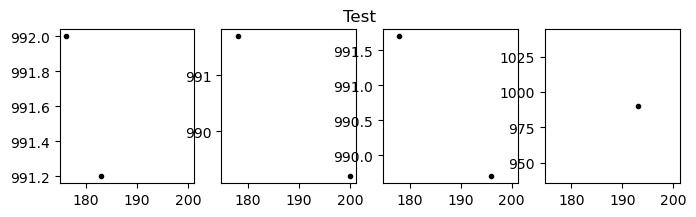

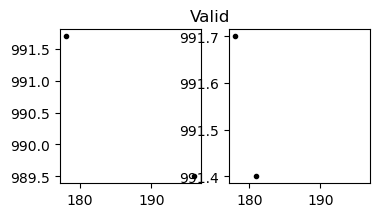

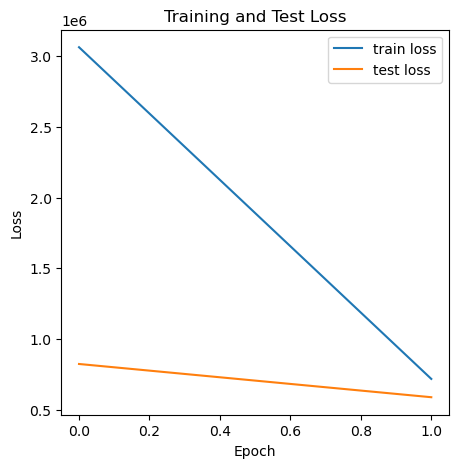

In [108]:
#First part
elev = np.array(altitude_list)

press = np.array(barometric_pressure_list)

#second part
""" Create a fake, noisy dataset. """
import matplotlib.pyplot as plt


# plot the noisy data
fig, ax = plt.subplots(figsize = (5,5))
ax.plot(elev, press, '.', label="data")
ax.set_xlabel("Elevation")
ax.set_ylabel("Pressure")
plt.show()

#third part
# convert x and y to pytorch tensors
# unsqueeze - converts x froo 1D to 2D
# to - converts x from type double (64 bit) to float (32 bit)
elevt = torch.from_numpy(elev).to(torch.float32).unsqueeze(1)
presst = torch.from_numpy(press).to(torch.float32).unsqueeze(1)

# instantiate the model
model_2 = MyNet(n_relus=2)

# run the model (make a prediction)
pred = model_2(elevt)

#part four
""" Train the model the better, but more complicated way. """

# set hyperparameters
learning_rate = 0.01
training_steps = 16
training_fraction = 0.7
test_fraction = 0.2
valid_fraction = 1 - (training_fraction -test_fraction)
batch_size = 2
num_epochs = 2
assert valid_fraction > 0, "Choose different values for test_fraction and training_fraction; valid_fraction is"

# define the model (and set the random number generator seed for reproducibility)
torch.manual_seed(5895)
model_2 = MyNet(n_relus = 10000)

# define the loss function
loss_fn = nn.MSELoss()

# define the optimizer
optim = torch.optim.Adam(model_2.parameters(), lr = learning_rate)

#***********************************************
# define the test, training, and validation sets
#***********************************************

# create random indicies
i_random = np.random.choice(len(elev), len(elev), replace = False)
train_ind_max = int(len(elev)*training_fraction)
train_inds = i_random[0:train_ind_max]
# define indices for testing data
test_ind_max = train_ind_max + int(len(elev)*test_fraction)
test_inds = i_random[train_ind_max:test_ind_max]
# for validation data
valid_inds = i_random[test_ind_max:]
print(f"training: {len(train_inds)}, test: {len(test_inds)}, valid: {len(valid_inds)}")

# define data loaders for the test, training, and validation datasets
from torch.utils.data import TensorDataset, DataLoader
#define a training loop
train_ds = TensorDataset(elevt[train_inds], presst[train_inds])
test_ds = TensorDataset(elevt[test_inds], presst[test_inds])
valid_ds = TensorDataset(elevt[valid_inds], presst[valid_inds])
#
train_dl = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
test_dl = DataLoader(test_ds, batch_size = batch_size, shuffle = True)
valid_dl = DataLoader(valid_ds, batch_size = batch_size, shuffle = True)

#define a training loop
# define an optimizer
def train_loop(data_loader, model, loss_fn, optim):
    # put the model into training mode
    model.train()

    # initialize the loss list
    batch_loss = []
    
    # do an optimization loop 
    # for n in range(training_steps):
    for bach, (xx, yy) in enumerate(data_loader):  

        # Changes:
        # * xt -> xx
        # * yt -> yy
        # * model_2 -> model   
    
        #calculate the prediction (run the model)
        pred = model_2(xx)

        # calculate the loss (pred is the prediction, yt is the tensor version of the training data)
        loss = loss_fn(pred, yy)

        # zero the gradients
        optim.zero_grad()

        # calculate the gradients of the parameter wrt loss
        loss.backward()

        # update the parameters (hopefully improve!)
        optim.step()

        # store the loss
        batch_loss.append(loss.item())
        
    # return the average loss
    return np.mean(batch_loss)

# define a testing loop 
def test_loop(data_loader, model, loss_fn):
    # put the model in avaluation mode
    model.eval()

    # initialize the loss list
    batch_loss = []

    # turn off gradient calculation
    with torch.no_grad():
        # loop over batches
        for batch, (xx, yy) in enumerate(data_loader):

            #run the model
            pred = model(xx)

            #calculate the loss
            loss = loss_fn(pred, yy)

            #store the loss
            batch_loss.append(loss.item())

    #return the average loss
    return np.mean(batch_loss)

test_loop(test_dl, model_2, loss_fn)

#part five
#data_load = train_dl
def visualize_dataloader(data_loader, tittle = None):
    N = len(data_loader)

    #create a 1xN figure
    fig, axs = plt.subplots(1, N, sharex = True,figsize = (2*N, 2))

    #Loop over batches & plot
    for i, (xx, yy) in enumerate(data_loader):
    #set the plot axis
        try:
            ax = axs[i]
        except TypeError:
            ax = axs
        ax.plot(xx, yy, 'k.')

    #add the tittle
    fig.suptitle(tittle)
    plt.show()

visualize_dataloader(train_dl, "Train")
visualize_dataloader(test_dl, "Test")
visualize_dataloader(valid_dl, "Valid")

#part six
"""THomas the Tank Engine the Model"""

# initialize lists to store the losses
train_loss = []
test_loss = []

# loop oer epochs
for epoch in range(num_epochs):

    # run a training loop and store loss
    train_loss_tmp = train_loop(train_dl, model_2, loss_fn, optim)
    train_loss.append(train_loss_tmp)
    
    # run a testing loop
    test_loss_tmp = test_loop(train_dl, model_2, loss_fn)
    #store the loss
    test_loss.append(test_loss_tmp)

# plot the losses as a function of epoch
fig, ax = plt.subplots(figsize=(5,5))
epochs_range = range(len(train_loss))  
ax.plot(epochs_range, train_loss, '-', label='train loss')
ax.plot(epochs_range, test_loss, '-', label='test loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.set_title('Training and Test Loss')
plt.show()